# Structured Five-Word Transformer - Seed 42 Analysis

This notebook shows only the **structured model trained with seed 42**.

Only seed 42 is loaded in every data and plotting cell. The protected test set is not read.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

PROJECT = Path(r"C:\Users\Shushant\Documents\ChatGPT\Whole transfoirmer\accuracy_research_project")
RUNS = PROJECT / "accuracy_research" / "experiments" / "architecture_20500" / "runs"

# Only seed 42 is included.
RUN_LABELS = {
    "structured_20500_seed42": "Structured - seed 42",
}
COLORS = {
    "structured_20500_seed42": "#2563EB",
}

histories = {
    name: json.loads((RUNS / name / "history.json").read_text(encoding="utf-8"))
    for name in RUN_LABELS
}
summaries = {
    name: json.loads((RUNS / name / "summary.json").read_text(encoding="utf-8"))
    for name in RUN_LABELS
}

print("Loaded model:")
for name in histories:
    print(f"- {RUN_LABELS[name]}: {len(histories[name])} completed epochs")

Loaded model:
- Structured - seed 42: 144 completed epochs


## Best seed-42 results

The code below finds the best validation epoch for the structured seed-42 model. Exact match is the main metric: all five words must be in exactly the correct order.

In [2]:
best_results = {}
for name, rows in histories.items():
    best = max(
        rows,
        key=lambda row: (
            row["exact_match_accuracy"],
            row["word_position_accuracy"],
        ),
    )
    best_results[name] = best
    print(
        f"{RUN_LABELS[name]}\n"
        f"  best epoch: {best['epoch']}\n"
        f"  stopped epoch: {rows[-1]['epoch']}\n"
        f"  exact match: {100 * best['exact_match_accuracy']:.2f}%\n"
        f"  word-position accuracy: {100 * best['word_position_accuracy']:.2f}%\n"
        f"  valid outputs: {100 * best['output_validity_rate']:.0f}%\n"
        f"  input words preserved: {100 * best['input_word_preservation_rate']:.0f}%\n"
    )

Structured - seed 42
  best epoch: 114
  stopped epoch: 144
  exact match: 75.85%
  word-position accuracy: 86.05%
  valid outputs: 100%
  input words preserved: 100%



## Architecture diagram

The structured seed-42 model receives the same five shuffled words. It scores explicit word relationships and restricts the answer to legal arrangements of the input words.

In [3]:
stages = [
    ("Five shuffled words", "Unordered input", "#DBEAFE"),
    ("Word + character", "Meaning and spelling", "#DCFCE7"),
    ("Transformer encoder", "Words examine context", "#FEF3C7"),
    ("Score 120 orders", "Only legal answers", "#FCE7F3"),
    ("Choose best order", "Preserve all words", "#EDE9FE"),
]

fig, ax = plt.subplots(figsize=(15, 4))
ax.set_xlim(0, 15)
ax.set_ylim(0, 4)
ax.axis("off")
for index, (title, subtitle, color) in enumerate(stages):
    x = 0.25 + index * 3
    box = FancyBboxPatch(
        (x, 1.15), 2.5, 1.5,
        boxstyle="round,pad=0.06,rounding_size=0.12",
        facecolor=color,
        edgecolor="#334155",
    )
    ax.add_patch(box)
    ax.text(x + 1.25, 2.08, title, ha="center", weight="bold", fontsize=10)
    ax.text(x + 1.25, 1.62, subtitle, ha="center", color="#475569", fontsize=9)
    if index < len(stages) - 1:
        ax.annotate(
            "", xy=(x + 2.92, 1.9), xytext=(x + 2.55, 1.9),
            arrowprops={"arrowstyle": "->", "color": "#334155", "lw": 1.8},
        )
ax.set_title("Seed-42 architecture flow", loc="left", fontsize=16, weight="bold")
plt.show()

<Figure size 1500x400 with 1 Axes>

## Training loss versus epoch

Training loss measures how well each model fits the examples used for learning. A falling curve means the optimizer is increasingly favoring the correct order. Its loss includes position, precedence, and adjacency signals in addition to the final ordering objective.

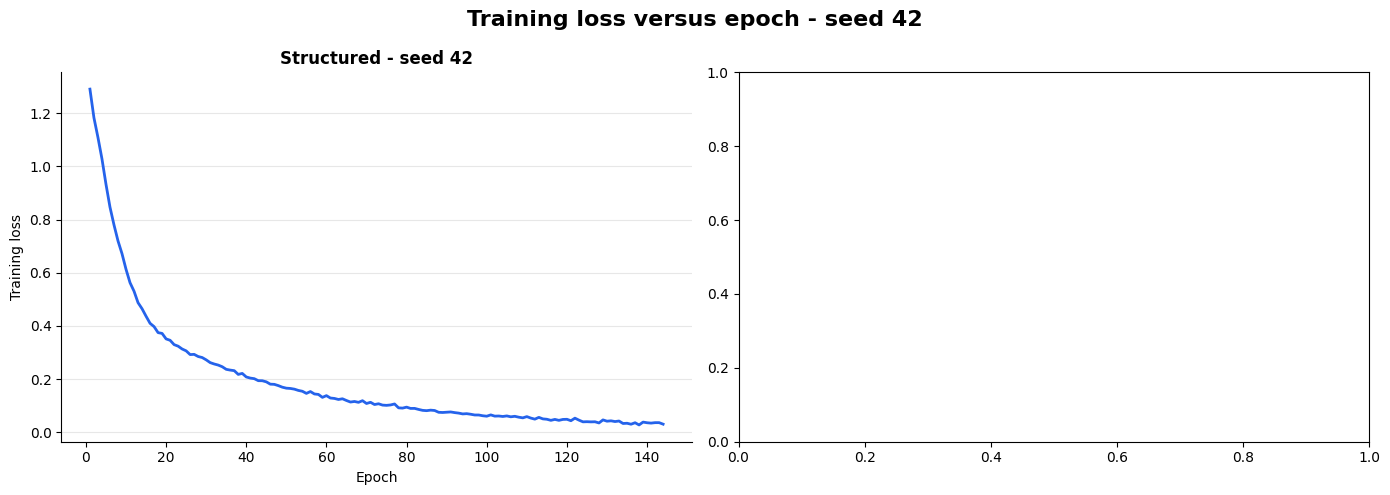

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, name in zip(axes, RUN_LABELS):
    rows = histories[name]
    axis.plot(
        [row["epoch"] for row in rows],
        [row["training_loss"] for row in rows],
        color=COLORS[name],
        linewidth=2,
    )
    axis.set_title(RUN_LABELS[name], weight="bold")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Training loss")
    axis.grid(axis="y", alpha=0.3)
    axis.spines[["top", "right"]].set_visible(False)
fig.suptitle("Training loss versus epoch - seed 42", fontsize=16, weight="bold")
fig.tight_layout()
plt.show()

## Validation loss versus epoch

Validation loss measures confidence on sentences excluded from training. It falls early and then rises, even while exact accuracy sometimes improves. This indicates overfitting and overconfidence: the model continues fitting training examples but becomes very confident about some incorrect validation orders.

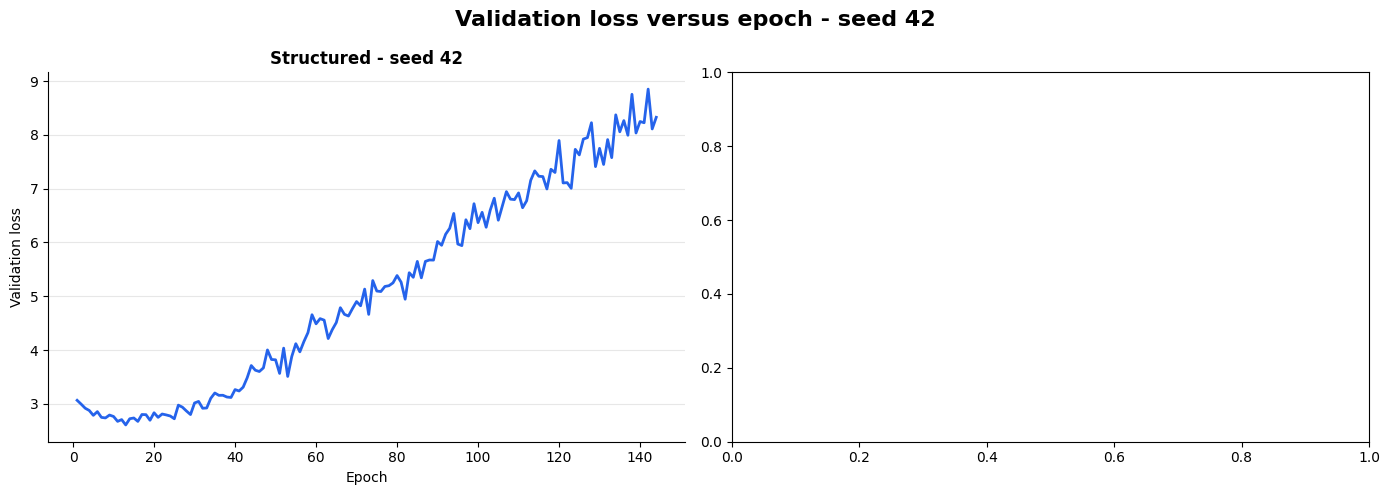

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, name in zip(axes, RUN_LABELS):
    rows = histories[name]
    axis.plot(
        [row["epoch"] for row in rows],
        [row["validation_loss"] for row in rows],
        color=COLORS[name],
        linewidth=2,
    )
    axis.set_title(RUN_LABELS[name], weight="bold")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Validation loss")
    axis.grid(axis="y", alpha=0.3)
    axis.spines[["top", "right"]].set_visible(False)
fig.suptitle("Validation loss versus epoch - seed 42", fontsize=16, weight="bold")
fig.tight_layout()
plt.show()

## Exact-match accuracy versus epoch

This is the main graph. Higher is better. One sentence counts as correct only if all five words are in exactly the target order. The structured seed-42 model reaches 75.85%; the candidate seed-42 model reaches 73.56%.

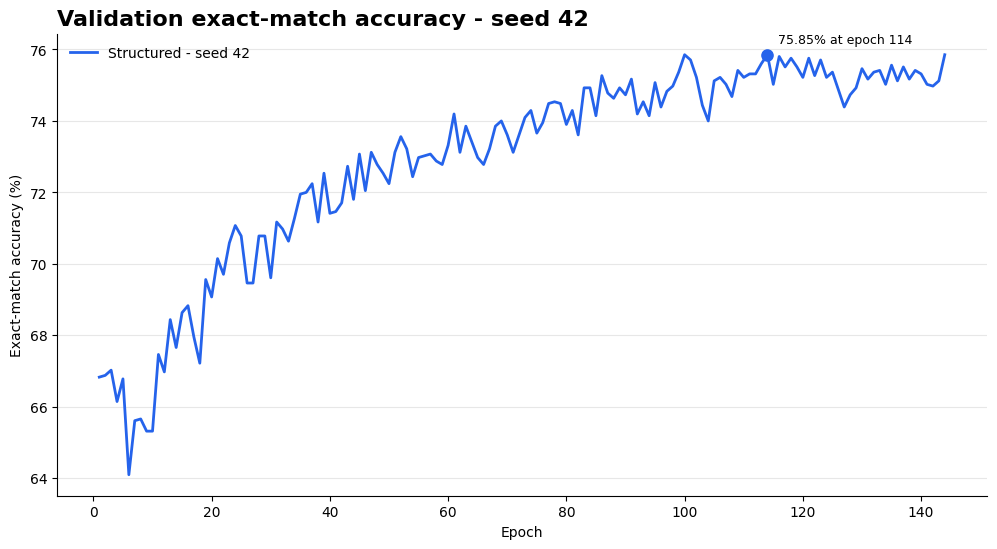

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
for name, rows in histories.items():
    ax.plot(
        [row["epoch"] for row in rows],
        [100 * row["exact_match_accuracy"] for row in rows],
        label=RUN_LABELS[name],
        color=COLORS[name],
        linewidth=2,
    )
    best = best_results[name]
    ax.scatter(
        best["epoch"], 100 * best["exact_match_accuracy"],
        color=COLORS[name], s=65, zorder=3,
    )
    ax.annotate(
        f"{100 * best['exact_match_accuracy']:.2f}% at epoch {best['epoch']}",
        (best["epoch"], 100 * best["exact_match_accuracy"]),
        xytext=(8, 8), textcoords="offset points", fontsize=9,
    )
ax.set_title("Validation exact-match accuracy - seed 42", loc="left", fontsize=16, weight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Exact-match accuracy (%)")
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Word-position accuracy versus epoch

This metric gives partial credit. If four of five words are correctly placed, the sentence receives 80% position accuracy even though exact match is zero. The gap between word-position and exact accuracy shows that many failures are near misses.

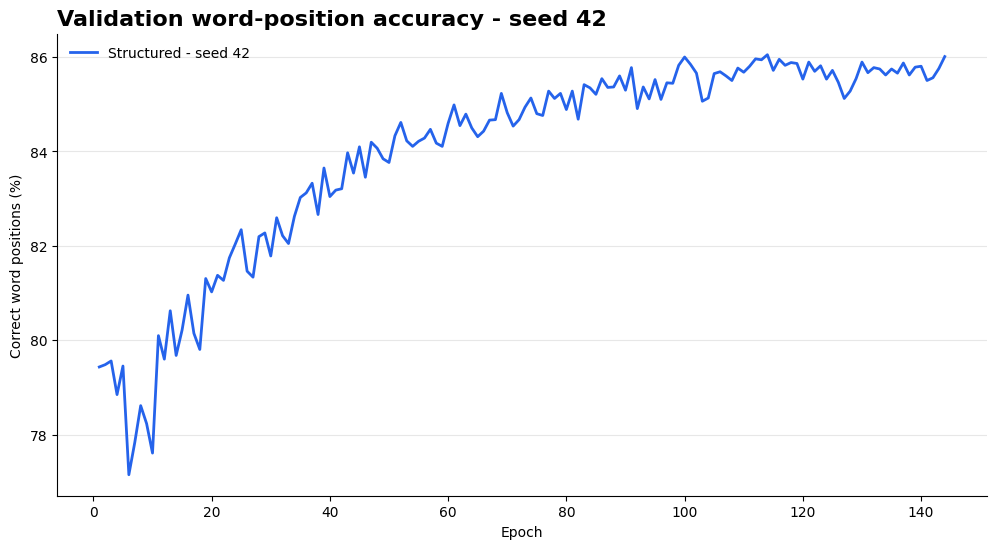

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
for name, rows in histories.items():
    ax.plot(
        [row["epoch"] for row in rows],
        [100 * row["word_position_accuracy"] for row in rows],
        label=RUN_LABELS[name],
        color=COLORS[name],
        linewidth=2,
    )
ax.set_title("Validation word-position accuracy - seed 42", loc="left", fontsize=16, weight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Correct word positions (%)")
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Dynamic learning rate versus epoch

The learning rate is the size of each optimization step. It rises during warmup and then gradually falls through cosine decay. The structured model uses a peak rate of 0.0004; the candidate model uses 0.0003.

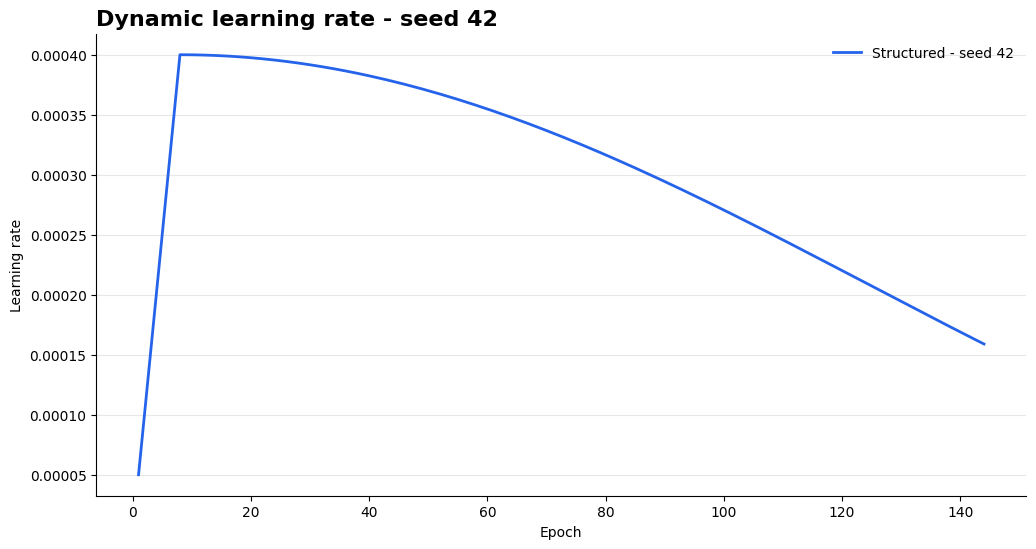

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
for name, rows in histories.items():
    ax.plot(
        [row["epoch"] for row in rows],
        [row["learning_rate"] for row in rows],
        label=RUN_LABELS[name],
        color=COLORS[name],
        linewidth=2,
    )
ax.set_title("Dynamic learning rate - seed 42", loc="left", fontsize=16, weight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Best accuracy and early stopping

Training retained the best checkpoint and stopped after 30 later epochs without improvement. The last epoch is therefore not the model we select.

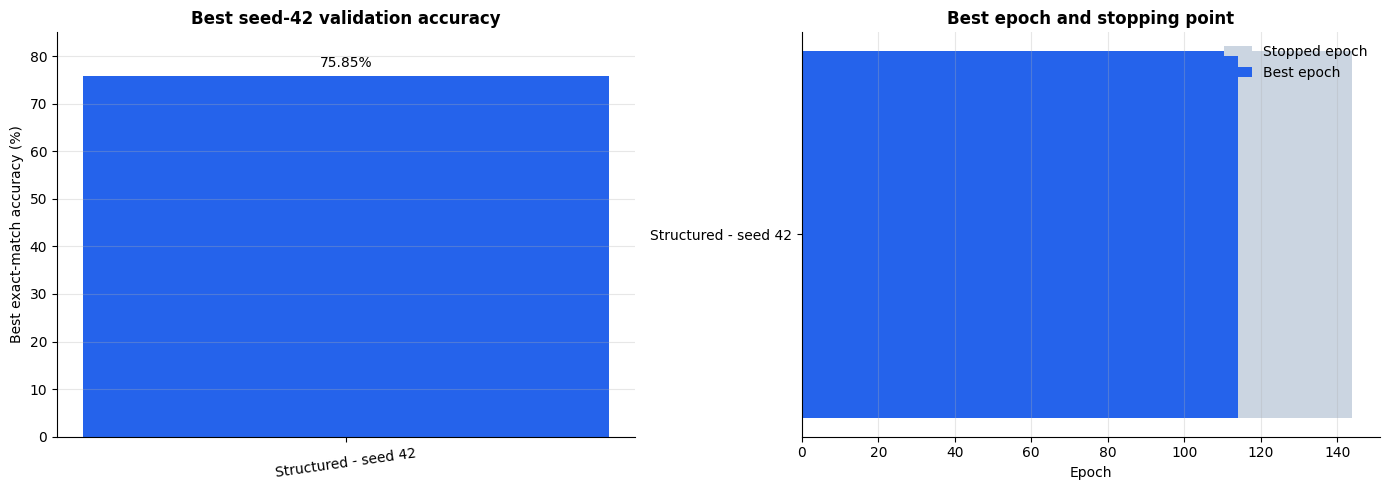

In [9]:
names = list(RUN_LABELS)
labels = [RUN_LABELS[name] for name in names]
best_accuracy = [100 * best_results[name]["exact_match_accuracy"] for name in names]
best_epochs = [best_results[name]["epoch"] for name in names]
stop_epochs = [histories[name][-1]["epoch"] for name in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(labels, best_accuracy, color=[COLORS[name] for name in names])
axes[0].bar_label(bars, labels=[f"{value:.2f}%" for value in best_accuracy], padding=4)
axes[0].set_ylim(0, 85)
axes[0].set_ylabel("Best exact-match accuracy (%)")
axes[0].set_title("Best seed-42 validation accuracy", weight="bold")
axes[0].tick_params(axis="x", rotation=8)
axes[0].grid(axis="y", alpha=0.3)

positions = range(len(names))
axes[1].barh(positions, stop_epochs, color="#CBD5E1", label="Stopped epoch")
axes[1].barh(positions, best_epochs, color=[COLORS[name] for name in names], label="Best epoch")
axes[1].set_yticks(list(positions), labels)
axes[1].invert_yaxis()
axes[1].set_xlabel("Epoch")
axes[1].set_title("Best epoch and stopping point", weight="bold")
axes[1].legend(frameon=False)
axes[1].grid(axis="x", alpha=0.3)
for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Seed-42 conclusions

- The structured seed-42 model is the strongest individual model: **75.85% exact match**.
- Candidate seed 42 reaches **73.56% exact match**.
- Both model produce **100% valid five-word outputs** and preserve **100% of input words**.
- Falling training loss with rising validation loss shows overfitting and confidence miscalibration.
- Early stopping correctly retained epoch 114 for both seed-42 model and stopped both at epoch 144.
- These are validation results, not protected test results.

### Why keep two seed-42 model?

The structured model behaves like a grammar analyst: it separately examines position, before-after relationships, and neighboring words. The candidate model behaves like a whole-sentence judge: it evaluates each complete ordering. They use the same seed but learn through different scoring architectures, so their mistakes may still differ.